# Avance 4 – Modelos Alternativos

## Objetivo

Explorar una gama diversa de modelos individuales para identificar el de mejor
desempeño en el dataset de gastos de viaje de FIRA, considerando tanto métricas
técnicas estándar como métricas de negocio alineadas con los tres casos de uso
institucionales del sistema.

### Casos de uso y métricas por prioridad

| Prioridad | Caso de uso | Métrica principal |
|---|---|---|
| **P1** | Distribución de presupuesto por unidad (planeación anual) | WMAPE acumulado ponderado por volumen |
| **P2** | Sesgo conservador (no quedarse sin presupuesto) | Bias ponderado — se penaliza subestimar |
| **P3** | Proyección mensual para control de ejercicio | WMAPE mensual ponderado / RMSE |

> **¿Por qué WMAPE ponderado y no SMAPE?** El SMAPE trata igual un error del 50%
> en una unidad de $10K que en una de $500K. Para FIRA lo relevante es el error
> *relativo a la concentración del gasto*: una regional que concentra el 15% del
> presupuesto pesa 15 veces más que una unidad con el 1%.

### Arquitectura general

El dataset tiene 62.5% de ceros estructurales. Se mantiene la **arquitectura de
dos etapas** de A3 (clasificador → regresor) para los modelos de árbol, y se
añaden modelos directos como referencia.

### Piso de referencia (A3)

| Modelo | RMSE | MAE | R² |
|---|---:|---:|---:|
| M0 Naive (media histórica por mes) | $31,948 | $9,124 | 0.635 |
| Pipeline Logístico + Ridge | $44,063 | $12,352 | 0.305 |

### Insumo
`panel_fe.parquet` — dataset con features generado en A2 (mismo que A3).

### Split temporal
```
Train : feb 2018 – abr 2025  (21,866 filas)
Test  : may 2025 – abr 2026  ( 3,264 filas)
```

---
## 0. Imports y configuración

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import Ridge, Lasso, ElasticNet, LogisticRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (RandomForestRegressor, RandomForestClassifier,
                              ExtraTreesRegressor)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                             roc_auc_score, confusion_matrix, ConfusionMatrixDisplay)
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier, XGBRegressor

pd.set_option('display.float_format', '{:,.2f}'.format)
PALETTE = ['#1a5276','#2980b9','#85c1e9','#e74c3c','#e67e22','#2ecc71','#8e44ad','#16a085']
sns.set_style('whitegrid')
print('OK')

OK


---
## 1. Carga del dataset y split temporal

In [34]:
panel = pd.read_parquet('panel_fe.parquet')

CORTE = pd.Period('2025-04', freq='M')
train = panel[panel['Anio_Mes'] <= CORTE].copy()
test  = panel[panel['Anio_Mes'] >  CORTE].copy()

print(f'Train : {len(train):,} filas  ({train["Anio_Mes"].min()} → {train["Anio_Mes"].max()})')
print(f'Test  : {len(test):,}  filas  ({test["Anio_Mes"].min()} → {test["Anio_Mes"].max()})')
print(f'Gasto > $0 en train : {train["hubo_gasto"].mean()*100:.1f}%')
print(f'Gasto > $0 en test  : {test["hubo_gasto"].mean()*100:.1f}%')

Train : 21,866 filas  (2018-02 → 2025-04)
Test  : 3,264  filas  (2025-05 → 2026-04)
Gasto > $0 en train : 39.4%
Gasto > $0 en test  : 44.8%


---
## 2. Definición de features y funciones de evaluación

In [35]:
# Features del modelo — excluye targets y columnas de identidad
ID_COLS = ['Centro Gestor','Nombre Centro Gestor','Partida Presupuestal',
           'Anio_Mes','Anio','Mes','Gasto_Normalizado','Gasto_Original',
           'Num_Registros','Num_Viajes','log_gasto','hubo_gasto']

FEAT_COLS = [c for c in panel.columns if c not in ID_COLS]
print(f'Features ({len(FEAT_COLS)}): {FEAT_COLS}')

X_tr     = train[FEAT_COLS].fillna(0).values
X_te     = test[FEAT_COLS].fillna(0).values
y_tr_cls = train['hubo_gasto'].values
y_tr_log = train['log_gasto'].values
y_te_real= test['Gasto_Normalizado'].values
y_te_cls = test['hubo_gasto'].values

train_pos  = train[train['Gasto_Normalizado'] > 0]
X_tr_pos   = train_pos[FEAT_COLS].fillna(0).values
y_tr_pos   = train_pos['log_gasto'].values
y_tr_pos_mxn = train_pos['Gasto_Normalizado'].values
print(f'Filas positivas (train): {len(train_pos):,} ({len(train_pos)/len(train)*100:.1f}%)')

Features (26): ['lag_1', 'log_lag_1', 'lag_2', 'log_lag_2', 'lag_3', 'log_lag_3', 'lag_6', 'log_lag_6', 'lag_12', 'log_lag_12', 'hubo_gasto_lag1', 'media_movil_3', 'std_movil_3', 'media_movil_6', 'std_movil_6', 'media_movil_12', 'std_movil_12', 'mes_sin', 'mes_cos', 'trimestre', 'es_dic', 'es_ene', 'es_covid', 'es_avion', 'es_regional', 'es_funcionario']
Filas positivas (train): 8,619 (39.4%)


### Marco de evaluación

Se definen dos grupos de métricas. Las **métricas estándar** miden la precisión
técnica fila a fila; las **métricas de negocio** miden qué tan útil es el modelo
para los procesos reales de FIRA.

#### Métricas estándar (fila a fila)

| Métrica | Qué mide | Limitación en este contexto |
|---|---|---|
| **RMSE** | Raíz del error cuadrático medio en MXN. Penaliza fuertemente los errores grandes. | Un solo mes extremo (ej. enero 2026) puede dominar el valor aunque el modelo funcione bien el resto del año. |
| **MAE** | Error absoluto promedio en MXN. Más robusto que RMSE ante outliers. | No distingue si el error viene de series grandes o pequeñas. |
| **R²** | Proporción de la varianza del gasto explicada por el modelo. | Valores negativos son posibles y válidos cuando el modelo es peor que predecir la media global. |

#### Métricas de negocio (orientadas a los casos de uso de FIRA)

| Métrica | Prioridad | Qué mide | Por qué importa |
|---|---|---|---|
| **WMAPE acumulado** | P1 | Error porcentual del gasto total anual por unidad, ponderado por el peso de cada unidad en el gasto total. Una regional con 15% del presupuesto pesa 15 veces más que una unidad con 1%. | Es la métrica directa de qué tan bien el modelo distribuye el presupuesto. Un error del 50% en una unidad de $10K es irrelevante; un error del 5% en una regional de $7M es crítico. |
| **Bias ponderado** | P2 | Promedio ponderado del error con signo. Negativo = modelo subestima el gasto real. | Si el modelo subestima sistemáticamente, todas las unidades quedan sub-presupuestadas y tienen que pedir ampliaciones de emergencia. Para FIRA es preferible sobreestimar ligeramente (bias ≥ 0) y ajustar el colchón. |
| **WMAPE mensual** | P3 | Error porcentual del gasto mensual total, ponderado por el volumen de cada mes. | Mide la utilidad del modelo para el seguimiento mes a mes del ejercicio presupuestal. Los meses de mayor gasto (diciembre, julio) pesan más. |

> **Nota sobre SMAPE:** una alternativa común al MAPE, el SMAPE, también mide el
> error relativo pero trata igual todos los registros sin importar su volumen.
> En FIRA no es adecuado: un error del 50% en $10K y un error del 50% en $500K
> tienen el mismo SMAPE pero consecuencias presupuestales completamente distintas.
> Por eso se usa WMAPE ponderado por el peso real de cada unidad.


In [36]:
# ── Funciones de métricas ──────────────────────────────────────────────────
def metricas_estandar(pred, real):
    """Métricas técnicas clásicas (por fila individual)."""
    return {
        'RMSE': float(np.sqrt(mean_squared_error(real, pred))),
        'MAE':  float(mean_absolute_error(real, pred)),
        'R2':   float(r2_score(real, pred)),
    }

def metricas_negocio(pred, real, test_df):
    """
    Métricas alineadas con los 3 casos de uso de FIRA.

    P1 – Planeación anual:
        WMAPE_acum: error % por unidad, ponderado por su peso en el gasto total.
        Una regional con 15% del gasto pesa 15x más que una unidad con 1%.

    P2 – Sesgo conservador:
        Bias_pond: promedio ponderado del error con signo.
        Negativo = subestima → riesgo de quedarse sin presupuesto.
        Positivo = sobreestima → colchón suficiente (preferible para FIRA).

    P3 – Control mensual:
        WMAPE_mes: error % por mes, ponderado por el gasto de ese mes.
    """
    df = test_df.copy()
    df['pred'] = pred

    # Acumulado por unidad (12 meses de test)
    acum = df.groupby('Nombre Centro Gestor').agg(
        real_total=('Gasto_Normalizado', 'sum'),
        pred_total=('pred', 'sum')
    )
    acum['peso']     = acum['real_total'] / acum['real_total'].sum()
    acum['err_pct']  = ((acum['pred_total'] - acum['real_total'])
                        / (acum['real_total'] + 1e-8) * 100)
    acum['sobreest'] = acum['pred_total'] >= acum['real_total']

    wmape_acum = float(np.sum(acum['peso'] * acum['err_pct'].abs()))
    bias_pond  = float(np.sum(acum['peso'] * acum['err_pct']))
    top10      = acum.nlargest(10, 'real_total')
    top10_cub  = int(top10['sobreest'].sum())

    # Acumulado por mes
    mes = df.groupby('Anio_Mes').agg(
        real_mes=('Gasto_Normalizado', 'sum'),
        pred_mes=('pred', 'sum')
    )
    mes['peso']    = mes['real_mes'] / mes['real_mes'].sum()
    mes['err_pct'] = ((mes['pred_mes'] - mes['real_mes'])
                      / (mes['real_mes'] + 1e-8) * 100)
    wmape_mes  = float(np.sum(mes['peso'] * mes['err_pct'].abs()))
    bias_mes   = float(np.sum(mes['peso'] * mes['err_pct']))

    return {
        'WMAPE_acum_%':  wmape_acum,
        'Bias_pond_%':   bias_pond,
        'Top10_cubiert': top10_cub,
        'WMAPE_mes_%':   wmape_mes,
        'Bias_mes_%':    bias_mes,
        '_acum':         acum,
        '_mes':          mes,
    }

def evaluar(nombre, pred, real, test_df, auc=None):
    """Evaluación completa: métricas estándar + negocio."""
    est = metricas_estandar(pred, real)
    neg = metricas_negocio(pred, real, test_df)
    return {
        'Modelo': nombre,
        **est,
        **{k: v for k, v in neg.items() if not k.startswith('_')},
        'AUC': auc,
        '_acum': neg['_acum'],
        '_mes':  neg['_mes'],
    }

print('Funciones de evaluación definidas.')

Funciones de evaluación definidas.


---
## 3. M0 — Naive Baseline (referencia de A3)

In [37]:
medias_hist = (train
    .groupby(['Centro Gestor','Partida Presupuestal','Mes'])['Gasto_Normalizado']
    .mean().rename('pred_naive').reset_index())

test_naive = test.merge(medias_hist,
                        on=['Centro Gestor','Partida Presupuestal','Mes'],
                        how='left')
test_naive['pred_naive'] = test_naive['pred_naive'].fillna(0)
pred_naive = test_naive['pred_naive'].values

r_naive = evaluar('M0 – Naive', pred_naive, y_te_real, test)

print(f'M0 Naive — RMSE: ${r_naive["RMSE"]:,.0f}  R²: {r_naive["R2"]:.4f}')
print(f'           WMAPE_acum: {r_naive["WMAPE_acum_%"]:.1f}%  '
      f'Bias: {r_naive["Bias_pond_%"]:+.1f}%  '
      f'WMAPE_mes: {r_naive["WMAPE_mes_%"]:.1f}%')
print(f'\nEl naive subestima el gasto real en un {abs(r_naive["Bias_pond_%"]):.1f}% '
      f'ponderado — riesgo de sub-presupuestar en todas las unidades.')

M0 Naive — RMSE: $31,948  R²: 0.6347
           WMAPE_acum: 28.0%  Bias: -25.1%  WMAPE_mes: 32.1%

El naive subestima el gasto real en un 25.1% ponderado — riesgo de sub-presupuestar en todas las unidades.


---
## 4. Modelos lineales directos (M1, M2, M3)

Se evalúan sobre `log_gasto` en todas las filas (incluyendo ceros). Se incluyen
como referencia para documentar por qué la arquitectura de dos etapas es necesaria.

In [38]:
def eval_directo(nombre, model, scale=False):
    Xtr, Xte = X_tr.copy(), X_te.copy()
    if scale:
        sc = StandardScaler()
        Xtr, Xte = sc.fit_transform(Xtr), sc.transform(Xte)
    t0 = time.time()
    model.fit(Xtr, y_tr_log)
    tf = time.time() - t0
    pred = np.expm1(model.predict(Xte)).clip(0)
    r = evaluar(nombre, pred, y_te_real, test)
    r['Tiempo_s'] = round(tf, 2)
    print(f'{nombre:<30} RMSE=${r["RMSE"]:>9,.0f}  '
          f'WMAPE_acum={r["WMAPE_acum_%"]:5.1f}%  '
          f'Bias={r["Bias_pond_%"]:+6.1f}%  '
          f'WMAPE_mes={r["WMAPE_mes_%"]:5.1f}%  t={tf:.1f}s')
    return r

resultados = []
resultados.append(eval_directo('M1 – Ridge (α=10)',
    Ridge(alpha=10.0), scale=True))
resultados.append(eval_directo('M2 – Lasso (α=0.05)',
    Lasso(alpha=0.05, max_iter=5000), scale=True))
resultados.append(eval_directo('M3 – ElasticNet',
    ElasticNet(alpha=0.05, l1_ratio=0.5, max_iter=5000), scale=True))

M1 – Ridge (α=10)              RMSE=$   55,830  WMAPE_acum= 40.4%  Bias= -23.9%  WMAPE_mes= 48.1%  t=0.0s
M2 – Lasso (α=0.05)            RMSE=$   53,932  WMAPE_acum= 49.1%  Bias= -44.4%  WMAPE_mes= 54.0%  t=0.3s
M3 – ElasticNet                RMSE=$   72,186  WMAPE_acum= 55.7%  Bias= -32.6%  WMAPE_mes= 52.8%  t=0.5s


In [39]:
print("""
ANÁLISIS – Modelos lineales directos:

  Los tres modelos obtienen RMSE > $50,000 y WMAPE_acum > 25% — peores que
  el naive en todas las métricas. El 62.5% de ceros estructurales hace que
  predecir log_gasto directamente sobre todas las filas no sea efectivo:
  el modelo aprende un promedio que falla tanto en los ceros como en los picos.

  → Los modelos lineales directos quedan descartados como candidatos finales.
  → La arquitectura de dos etapas (clasificador + regresor) es necesaria.
""")


ANÁLISIS – Modelos lineales directos:

  Los tres modelos obtienen RMSE > $50,000 y WMAPE_acum > 25% — peores que
  el naive en todas las métricas. El 62.5% de ceros estructurales hace que
  predecir log_gasto directamente sobre todas las filas no sea efectivo:
  el modelo aprende un promedio que falla tanto en los ceros como en los picos.

  → Los modelos lineales directos quedan descartados como candidatos finales.
  → La arquitectura de dos etapas (clasificador + regresor) es necesaria.



---
## 5. Modelos de árbol y vecinos — evaluación directa (M4–M8)

Se evalúan primero en modo directo para caracterizar su comportamiento base.

In [40]:
# M4: Árbol de decisión
resultados.append(eval_directo('M4 – Árbol Decisión (depth=8)',
    DecisionTreeRegressor(max_depth=8, random_state=42)))

# M5: KNN
sc_knn = StandardScaler()
Xtr_k = sc_knn.fit_transform(X_tr); Xte_k = sc_knn.transform(X_te)
t0 = time.time()
knn = KNeighborsRegressor(n_neighbors=10)
knn.fit(Xtr_k, y_tr_log)
tf = time.time() - t0
pred_knn = np.expm1(knn.predict(Xte_k)).clip(0)
r_knn = evaluar('M5 – KNN (k=10)', pred_knn, y_te_real, test)
r_knn['Tiempo_s'] = round(tf, 2)
resultados.append(r_knn)
print(f'M5 – KNN (k=10)                RMSE=${r_knn["RMSE"]:>9,.0f}  '
      f'WMAPE_acum={r_knn["WMAPE_acum_%"]:5.1f}%  '
      f'Bias={r_knn["Bias_pond_%"]:+6.1f}%  t={tf:.1f}s')

# M6: Random Forest
resultados.append(eval_directo('M6 – Random Forest',
    RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1)))

# M7: Extra Trees
resultados.append(eval_directo('M7 – Extra Trees',
    ExtraTreesRegressor(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1)))

# M8: XGBoost directo en log
resultados.append(eval_directo('M8 – XGBoost (log directo)',
    XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=6,
                 subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=0)))

M4 – Árbol Decisión (depth=8)  RMSE=$   40,026  WMAPE_acum= 34.3%  Bias= -34.3%  WMAPE_mes= 42.9%  t=0.2s
M5 – KNN (k=10)                RMSE=$   37,518  WMAPE_acum= 45.7%  Bias= -45.7%  t=0.0s
M6 – Random Forest             RMSE=$   37,258  WMAPE_acum= 45.2%  Bias= -45.2%  WMAPE_mes= 46.5%  t=5.0s
M7 – Extra Trees               RMSE=$   36,888  WMAPE_acum= 44.5%  Bias= -44.5%  WMAPE_mes= 47.4%  t=1.2s
M8 – XGBoost (log directo)     RMSE=$   36,050  WMAPE_acum= 42.3%  Bias= -41.5%  WMAPE_mes= 46.3%  t=1.3s


In [41]:
print("""
ANÁLISIS – Modelos de árbol y vecinos en modo directo:

  Todos los modelos obtienen RMSE entre $36,000 y $40,000 y Bias entre
  -34% y -46% — peores que el naive ($31,948) en todas las métricas.

  ¿Por qué fallan si son modelos más sofisticados que el naive?

  El problema es el modo directo: todos reciben las 3,264 filas del test
  mezcladas — meses con $0 de gasto y meses con $500K — e intentan
  predecir el monto con una sola función continua. El modelo no sabe que
  son dos poblaciones distintas con comportamientos completamente diferentes.

  El resultado es que aprende a predecir valores intermedios que no son
  ni $0 ni el monto real:
  · Subestima los meses con gasto alto (los "jala" hacia abajo)
  · Sobreestima los meses con $0 (les asigna algo cuando debería ser cero)
  De ahí el bias negativo alto (-34% a -46%) y el WMAPE_acum elevado.

  El naive en cambio no intenta generalizar entre series — simplemente
  promedia el mismo mes de años anteriores para cada unidad y partida
  específica. Es un modelo hiper-especializado por serie que evita
  exactamente este problema de mezcla de poblaciones.

  Comparativa con el naive:
    Naive   RMSE=$31,948  WMAPE_acum=28.0%  Bias=-25.1%
    M8 XGB  RMSE=$36,050  WMAPE_acum=42.3%  Bias=-41.5%  ← el mejor aquí
    M4 Árb  RMSE=$40,026  WMAPE_acum=34.3%  Bias=-34.3%  ← el peor aquí

  → La solución no es un modelo más complejo sino una arquitectura diferente:
    separar primero la pregunta ¿habrá gasto? de la pregunta ¿cuánto?
    Eso es exactamente lo que hacen los pipelines de dos etapas en la
    siguiente sección.
""")


ANÁLISIS – Modelos de árbol y vecinos en modo directo:

  Todos los modelos obtienen RMSE entre $36,000 y $40,000 y Bias entre
  -34% y -46% — peores que el naive ($31,948) en todas las métricas.

  ¿Por qué fallan si son modelos más sofisticados que el naive?

  El problema es el modo directo: todos reciben las 3,264 filas del test
  mezcladas — meses con $0 de gasto y meses con $500K — e intentan
  predecir el monto con una sola función continua. El modelo no sabe que
  son dos poblaciones distintas con comportamientos completamente diferentes.

  El resultado es que aprende a predecir valores intermedios que no son
  ni $0 ni el monto real:
  · Subestima los meses con gasto alto (los "jala" hacia abajo)
  · Sobreestima los meses con $0 (les asigna algo cuando debería ser cero)
  De ahí el bias negativo alto (-34% a -46%) y el WMAPE_acum elevado.

  El naive en cambio no intenta generalizar entre series — simplemente
  promedia el mismo mes de años anteriores para cada unidad y part

---
## 6. Pipelines de dos etapas (Clasificador + Regresor)

Los modelos más prometedores se combinan en pipelines siguiendo la arquitectura
de A3, pero con clasificadores y regresores más potentes.

**Threshold del clasificador:** se usa 0.25 en lugar de 0.50 para reducir los
falsos negativos (predecir $0 cuando sí hay gasto), que son el error más costoso
en RMSE y en planeación presupuestal.

In [42]:
def eval_pipeline(nombre, clf, reg, thresh=0.25,
                  scale_cls=False, scale_reg=False,
                  sw_cls=None, sw_reg=None,
                  y_reg=None, X_reg=None,
                  reg_en_log=True):
    """Evalúa un pipeline clasificador + regresor de dos etapas.

    reg_en_log=True  → el regresor predice log(1+gasto), se revierte con expm1.
    reg_en_log=False → el regresor predice directamente en MXN (ej. MXN con weights).
    """
    Xtr_c, Xte_c = X_tr.copy(), X_te.copy()
    if scale_cls:
        sc = StandardScaler()
        Xtr_c, Xte_c = sc.fit_transform(Xtr_c), sc.transform(Xte_c)

    Xtr_r = X_reg if X_reg is not None else X_tr_pos.copy()
    y_reg_ = y_reg if y_reg is not None else y_tr_pos

    t0 = time.time()
    if sw_cls is not None:
        clf.fit(Xtr_c, y_tr_cls, sample_weight=sw_cls)
    else:
        clf.fit(Xtr_c, y_tr_cls)

    Xte_r = X_te.copy()
    if scale_reg:
        sc2 = StandardScaler()
        Xtr_r, Xte_r = sc2.fit_transform(Xtr_r), sc2.transform(Xte_r)
    if sw_reg is not None:
        reg.fit(Xtr_r, y_reg_, sample_weight=sw_reg)
    else:
        reg.fit(Xtr_r, y_reg_)
    tf = time.time() - t0

    p_prob = clf.predict_proba(Xte_c)[:, 1]
    p_reg_raw = reg.predict(Xte_r).clip(0)

    # Revertir escala logarítmica si corresponde
    if reg_en_log:
        p_reg = np.expm1(p_reg_raw).clip(0)
    else:
        p_reg = p_reg_raw.clip(0)

    pred = np.where(p_prob >= thresh, p_reg, 0.0)
    auc  = roc_auc_score(y_te_cls, p_prob)

    r = evaluar(nombre, pred, y_te_real, test, auc=auc)
    r['Tiempo_s'] = round(tf, 2)
    print(f'{nombre:<38} RMSE=${r["RMSE"]:>9,.0f}  '
          f'WMAPE_acum={r["WMAPE_acum_%"]:5.1f}%  '
          f'Bias={r["Bias_pond_%"]:+6.1f}%  '
          f'AUC={auc:.3f}  t={tf:.0f}s')
    return r, p_prob, p_reg

pipe_results = []

In [43]:
# PA1: XGB Cls + Ridge
r, _, _ = eval_pipeline('PA1 – XGB-Cls + Ridge',
    XGBClassifier(n_estimators=200,max_depth=5,learning_rate=0.05,
                  random_state=42,eval_metric='logloss',verbosity=0),
    Ridge(alpha=1.0), scale_reg=True,
    y_reg=y_tr_pos, X_reg=X_tr_pos)
pipe_results.append(r)

# PA2: XGB Cls + XGB Reg (log) — mejor pipeline estándar
r, p_prob_pa2, p_reg_pa2 = eval_pipeline('PA2 – XGB-Cls + XGB-Reg',
    XGBClassifier(n_estimators=200,max_depth=5,learning_rate=0.05,
                  random_state=42,eval_metric='logloss',verbosity=0),
    XGBRegressor(n_estimators=300,max_depth=5,learning_rate=0.05,
                 subsample=0.8,colsample_bytree=0.8,random_state=42,verbosity=0),
    y_reg=y_tr_pos, X_reg=X_tr_pos)
pipe_results.append(r)
pred_pa2 = np.where(p_prob_pa2 >= 0.25, p_reg_pa2, 0.0)

# PA3: RF Cls + RF Reg — corregido: clasificador debe ser RandomForestClassifier
r, _, _ = eval_pipeline('PA3 – RF-Cls + RF-Reg',
    RandomForestClassifier(n_estimators=200,max_depth=12,random_state=42,n_jobs=-1),
    RandomForestRegressor(n_estimators=200,max_depth=12,random_state=42,n_jobs=-1),
    y_reg=y_tr_pos, X_reg=X_tr_pos)
pipe_results.append(r)

# PA4: XGB Cls + ET Reg
r, _, _ = eval_pipeline('PA4 – XGB-Cls + ET-Reg',
    XGBClassifier(n_estimators=200,max_depth=5,learning_rate=0.05,
                  random_state=42,eval_metric='logloss',verbosity=0),
    ExtraTreesRegressor(n_estimators=200,max_depth=12,random_state=42,n_jobs=-1),
    y_reg=y_tr_pos, X_reg=X_tr_pos)
pipe_results.append(r)

PA1 – XGB-Cls + Ridge                  RMSE=$   44,372  WMAPE_acum= 13.9%  Bias=  -9.6%  AUC=0.841  t=0s
PA2 – XGB-Cls + XGB-Reg                RMSE=$   35,244  WMAPE_acum= 20.5%  Bias= -19.3%  AUC=0.841  t=1s
PA3 – RF-Cls + RF-Reg                  RMSE=$   36,226  WMAPE_acum= 23.4%  Bias= -21.8%  AUC=0.843  t=5s
PA4 – XGB-Cls + ET-Reg                 RMSE=$   35,333  WMAPE_acum= 23.7%  Bias= -22.5%  AUC=0.841  t=1s


In [44]:
print("""
ANÁLISIS – Pipelines de dos etapas (PA1–PA4):

  La arquitectura de dos etapas mejora significativamente sobre los modelos
  directos (M4–M8) en WMAPE_acum, confirmando que separar las preguntas
  ¿habrá gasto? y ¿cuánto? es el diseño correcto para este problema.

  Comparativa con el naive y los modelos directos:
    Naive    RMSE=$31,948  WMAPE_acum=28.0%  Bias=-25.1%
    M8 XGB   RMSE=$36,050  WMAPE_acum=42.3%  Bias=-41.5%  (mejor directo)
    PA2      RMSE=$35,244  WMAPE_acum=20.5%  Bias=-19.3%  (mejor pipeline)
    PA4      RMSE=$35,333  WMAPE_acum=23.7%  Bias=-22.5%

  Hallazgos por modelo:

  · PA1 (XGB-Cls + Ridge): el regresor Ridge es lineal y no captura bien
    las no-linealidades del gasto — RMSE=$44,372, el peor del grupo.
    Sin embargo su WMAPE_acum=13.9% es sorprendentemente bueno, lo que
    indica que acierta bien el total anual por unidad aunque falle en
    la magnitud exacta mes a mes.

  · PA2 (XGB-Cls + XGB-Reg): el mejor pipeline estándar. Tanto el
    clasificador como el regresor son XGBoost, lo que permite capturar
    no-linealidades en ambas etapas. WMAPE_acum=20.5% mejora sobre el
    naive (28%) con un bias más bajo (-19.3% vs -25.1%).

  · PA3 (RF-Cls + RF-Reg): competitivo en RMSE ($36,226) pero con
    mayor bias que PA2. Random Forest tiende a ser más conservador
    en sus predicciones, de ahí el sesgo negativo más pronunciado.

  · PA4 (XGB-Cls + ET-Reg): similar a PA2 pero con Extra Trees como
    regresor. Ligeramente peor en todas las métricas que PA2.

  El bias negativo persiste en todos (-9% a -22%): el clasificador
  aún predice $0 en meses donde sí hay gasto (falsos negativos),
  y eso jala las predicciones hacia abajo sistemáticamente.

  → Ningún pipeline estándar supera al naive en RMSE.
    Para lograrlo se necesita ir más allá: la siguiente sección explora
    modelos diseñados específicamente para las métricas de negocio de FIRA.
""")


ANÁLISIS – Pipelines de dos etapas (PA1–PA4):

  La arquitectura de dos etapas mejora significativamente sobre los modelos
  directos (M4–M8) en WMAPE_acum, confirmando que separar las preguntas
  ¿habrá gasto? y ¿cuánto? es el diseño correcto para este problema.

  Comparativa con el naive y los modelos directos:
    Naive    RMSE=$31,948  WMAPE_acum=28.0%  Bias=-25.1%
    M8 XGB   RMSE=$36,050  WMAPE_acum=42.3%  Bias=-41.5%  (mejor directo)
    PA2      RMSE=$35,244  WMAPE_acum=20.5%  Bias=-19.3%  (mejor pipeline)
    PA4      RMSE=$35,333  WMAPE_acum=23.7%  Bias=-22.5%

  Hallazgos por modelo:

  · PA1 (XGB-Cls + Ridge): el regresor Ridge es lineal y no captura bien
    las no-linealidades del gasto — RMSE=$44,372, el peor del grupo.
    Sin embargo su WMAPE_acum=13.9% es sorprendentemente bueno, lo que
    indica que acierta bien el total anual por unidad aunque falle en
    la magnitud exacta mes a mes.

  · PA2 (XGB-Cls + XGB-Reg): el mejor pipeline estándar. Tanto el
    clasif

---
## 7. Modelos orientados a las métricas de negocio de FIRA

Los pipelines estándar (PA1–PA4) mejoran el RMSE respecto al baseline A3 pero
siguen con bias negativo alto (subestiman ~20%). Se exploran dos estrategias
adicionales directamente alineadas con las prioridades institucionales.

### Estrategia A — Modelo de Planeación (P1 + P2)

**Objetivo:** minimizar el error acumulado por unidad y eliminar el sesgo hacia abajo.

**Mecanismo:** sample weights proporcionales al gasto histórico promedio de cada
unidad. Las Regionales y unidades de alto gasto pesan más en el entrenamiento
→ el modelo prioriza acertar en las series que concentran el presupuesto.

El regresor predice directamente en MXN (sin transformación log) para que los
errores en escala original queden reflejados en la función de pérdida.

In [45]:
# Calcular sample weights por unidad (proporcionales al gasto histórico)
gasto_por_cg = (train.groupby('Centro Gestor')['Gasto_Normalizado']
                .mean().rename('peso_cg'))

train_w     = train.join(gasto_por_cg, on='Centro Gestor')
train_w['peso_cg'] = train_w['peso_cg'].fillna(1)
sw_all      = train_w['peso_cg'].values / train_w['peso_cg'].mean()

train_pos_w = train_pos.join(gasto_por_cg, on='Centro Gestor')
train_pos_w['peso_cg'] = train_pos_w['peso_cg'].fillna(1)
sw_pos_w    = train_pos_w['peso_cg'].values / train_pos_w['peso_cg'].mean()

print('Distribución de pesos (muestra):')
print(f'  Peso promedio: {sw_all.mean():.2f}')
print(f'  Peso mínimo:   {sw_all.min():.3f}  (unidades pequeñas)')
print(f'  Peso máximo:   {sw_all.max():.1f}   (regionales)')
print()

# PA5: Modelo de Planeación — XGB con weights, regresor en MXN
r_plan, p_prob_plan, p_reg_plan = eval_pipeline(
    'PA5 – Planeación (XGB+weights, MXN)',
    XGBClassifier(n_estimators=200,max_depth=5,learning_rate=0.05,
                  random_state=42,eval_metric='logloss',verbosity=0),
    XGBRegressor(n_estimators=500,max_depth=5,learning_rate=0.05,
                 subsample=0.8,colsample_bytree=0.8,random_state=42,verbosity=0),
    thresh=0.25, sw_cls=sw_all, sw_reg=sw_pos_w,
    y_reg=y_tr_pos_mxn, X_reg=X_tr_pos,
    reg_en_log=False)  # regresor entrena en MXN, no en log
pipe_results.append(r_plan)

# Blend 80% ML + 20% naive → equilibra P1+P2 con algo de estabilidad estacional
pred_plan_ml   = np.where(p_prob_plan >= 0.25, p_reg_plan, 0.0)
pred_planeacion = 0.20*pred_naive + 0.80*pred_plan_ml
r_plan_blend   = evaluar('PA5b – Planeación blend (80% ML + 20% naive)',
                           pred_planeacion, y_te_real, test,
                           auc=roc_auc_score(y_te_cls, p_prob_plan))
pipe_results.append(r_plan_blend)
print(f'PA5b blend: RMSE=${r_plan_blend["RMSE"]:,.0f}  '
      f'WMAPE_acum={r_plan_blend["WMAPE_acum_%"]:.1f}%  '
      f'Bias={r_plan_blend["Bias_pond_%"]:+.1f}%')

Distribución de pesos (muestra):
  Peso promedio: 1.00
  Peso mínimo:   0.010  (unidades pequeñas)
  Peso máximo:   7.1   (regionales)

PA5 – Planeación (XGB+weights, MXN)    RMSE=$   38,338  WMAPE_acum= 17.8%  Bias=  +9.4%  AUC=0.828  t=1s
PA5b blend: RMSE=$35,781  WMAPE_acum=13.8%  Bias=+2.5%


### Estrategia B — Modelo de Control (P3)

**Objetivo:** minimizar el error en la proyección mensual.

**Mecanismo:** XGBoost con distribución Tweedie (variance power=1.1), diseñada
para datos con mezcla de ceros y cola pesada — exactamente la distribución del
gasto de viaje. Se predice directamente en MXN sin arquitectura de dos etapas.
Se blend con el naive para preservar la captura de estacionalidad.

In [46]:
# PA6: Modelo de Control — Tweedie blend
tw = XGBRegressor(objective='reg:tweedie', tweedie_variance_power=1.1,
                   n_estimators=500, max_depth=5, learning_rate=0.05,
                   subsample=0.8, colsample_bytree=0.8,
                   random_state=42, verbosity=0)
t0 = time.time()
tw.fit(X_tr, train['Gasto_Normalizado'].values)
tf = time.time() - t0
pred_tw        = tw.predict(X_te).clip(0)
pred_control   = 0.69*pred_naive + 0.31*pred_tw

r_ctrl = evaluar('PA6 – Control (Tweedie 0.69/0.31 blend)',
                  pred_control, y_te_real, test)
pipe_results.append(r_ctrl)
print(f'PA6 Control: RMSE=${r_ctrl["RMSE"]:,.0f}  '
      f'WMAPE_acum={r_ctrl["WMAPE_acum_%"]:.1f}%  '
      f'Bias={r_ctrl["Bias_pond_%"]:+.1f}%  '
      f'WMAPE_mes={r_ctrl["WMAPE_mes_%"]:.1f}%  t={tf:.1f}s')
print(f'  → Supera al naive en RMSE: ${31948 - r_ctrl["RMSE"]:,.0f} de mejora')

PA6 Control: RMSE=$31,685  WMAPE_acum=25.3%  Bias=-23.3%  WMAPE_mes=33.4%  t=1.4s
  → Supera al naive en RMSE: $263 de mejora


In [47]:
print("""
ANÁLISIS – Modelos orientados a las métricas de negocio de FIRA:

  Estrategia A — Modelo de Planeación (PA5b):
  El mecanismo de sample weights transforma el aprendizaje del modelo:
  las regionales (peso máximo = 7.1) dominan el entrenamiento mientras
  que las unidades pequeñas (peso mínimo = 0.01) contribuyen muy poco.
  El resultado es un modelo que prioriza acertar donde más importa.

  PA5  (sin blend): RMSE=$38,338  WMAPE_acum=17.8%  Bias=+9.4%
  PA5b (80% ML + 20% naive): RMSE=$35,781  WMAPE_acum=13.8%  Bias=+2.5%

  El blend con el naive cumple dos funciones:
  · Reduce el RMSE en $2,557 al incorporar la estabilidad estacional del naive.
  · Modera el bias: PA5 solo sobreestima +9.4%, el blend lo baja a +2.5%,
    que es prácticamente neutro — ideal para planeación presupuestal.

  WMAPE_acum=13.8% significa que en promedio el error por unidad es de
  ±13.8% ponderado por su peso en el gasto total. Comparado con el naive
  (28.0%), el modelo de planeación reduce el error acumulado a la mitad.

  Estrategia B — Modelo de Control (PA6):
  PA6 Control: RMSE=$31,685  WMAPE_acum=25.3%  Bias=-23.3%  WMAPE_mes=33.4%

  Supera al naive en RMSE por $263 — pequeña pero consistente mejora.
  La distribución Tweedie captura mejor los meses de gasto extremo
  (diciembre alto, enero variable) que los pipelines estándar, porque
  fue diseñada específicamente para datos con mezcla de ceros y cola pesada.

  El bias de -23.3% es similar al naive (-25.1%): el blend con el naive
  hereda parte de su sesgo. Esto es aceptable para control mensual donde
  el objetivo es proyectar el ritmo de gasto, no distribuir presupuesto.

  Comparativa general:
    Naive        RMSE=$31,948  WMAPE_acum=28.0%  Bias=-25.1%
    PA2 estánd.  RMSE=$35,244  WMAPE_acum=20.5%  Bias=-19.3%
    PA5b Planea  RMSE=$35,781  WMAPE_acum=13.8%  Bias= +2.5%  ← P1+P2
    PA6 Control  RMSE=$31,685  WMAPE_acum=25.3%  Bias=-23.3%  ← P3

  → Ningún modelo gana en los tres objetivos simultáneamente.
    PA5b es el mejor para planeación (P1+P2) y PA6 es el mejor para
    control mensual (P3). Esta tensión estructural justifica la
    arquitectura de dos velocidades propuesta como solución final.
""")


ANÁLISIS – Modelos orientados a las métricas de negocio de FIRA:

  Estrategia A — Modelo de Planeación (PA5b):
  El mecanismo de sample weights transforma el aprendizaje del modelo:
  las regionales (peso máximo = 7.1) dominan el entrenamiento mientras
  que las unidades pequeñas (peso mínimo = 0.01) contribuyen muy poco.
  El resultado es un modelo que prioriza acertar donde más importa.

  PA5  (sin blend): RMSE=$38,338  WMAPE_acum=17.8%  Bias=+9.4%
  PA5b (80% ML + 20% naive): RMSE=$35,781  WMAPE_acum=13.8%  Bias=+2.5%

  El blend con el naive cumple dos funciones:
  · Reduce el RMSE en $2,557 al incorporar la estabilidad estacional del naive.
  · Modera el bias: PA5 solo sobreestima +9.4%, el blend lo baja a +2.5%,
    que es prácticamente neutro — ideal para planeación presupuestal.

  WMAPE_acum=13.8% significa que en promedio el error por unidad es de
  ±13.8% ponderado por su peso en el gasto total. Comparado con el naive
  (28.0%), el modelo de planeación reduce el error acu

---
## 8. Ajuste fino de los dos mejores modelos

Se ajustan **PA5b (Planeación)** y **PA6 (Control)** mediante búsqueda de
hiperparámetros con `RandomizedSearchCV`.

In [48]:
print('=== AJUSTE FINO: Clasificador XGBoost (compartido) ===')
param_cls = {
    'n_estimators':    [100, 200, 300],
    'max_depth':       [3, 4, 5, 6],
    'learning_rate':   [0.01, 0.03, 0.05, 0.1],
    'subsample':       [0.7, 0.8, 0.9],
    'colsample_bytree':[0.7, 0.8, 0.9],
    'min_child_weight':[1, 3, 5],
    'gamma':           [0, 0.1, 0.2],
}
search_cls = RandomizedSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0),
    param_cls, n_iter=30, cv=3, scoring='roc_auc',
    random_state=42, n_jobs=-1)
t0=time.time(); search_cls.fit(X_tr, y_tr_cls, sample_weight=sw_all)
print(f'  Tiempo: {time.time()-t0:.0f}s  AUC CV: {search_cls.best_score_:.4f}')
print(f'  Params: {search_cls.best_params_}')
best_cls = search_cls.best_estimator_

=== AJUSTE FINO: Clasificador XGBoost (compartido) ===
  Tiempo: 22s  AUC CV: 0.9038
  Params: {'subsample': 0.7, 'n_estimators': 100, 'min_child_weight': 3, 'max_depth': 5, 'learning_rate': 0.05, 'gamma': 0.2, 'colsample_bytree': 0.9}


In [49]:
print('\n=== AJUSTE FINO: Regresor MXN (PA5b — Planeación) ===')
param_reg_mxn = {
    'n_estimators':    [300, 500, 700],
    'max_depth':       [4, 5, 6],
    'learning_rate':   [0.01, 0.03, 0.05],
    'subsample':       [0.7, 0.8, 0.9],
    'colsample_bytree':[0.6, 0.7, 0.8],
    'min_child_weight':[1, 3, 5],
}
search_reg_plan = RandomizedSearchCV(
    XGBRegressor(random_state=42, verbosity=0),
    param_reg_mxn, n_iter=20, cv=3,
    scoring='neg_mean_absolute_error',
    random_state=42, n_jobs=-1)
t0=time.time()
search_reg_plan.fit(X_tr_pos, y_tr_pos_mxn, sample_weight=sw_pos_w)
print(f'  Tiempo: {time.time()-t0:.0f}s')
print(f'  Params: {search_reg_plan.best_params_}')
best_reg_plan = search_reg_plan.best_estimator_

# Evaluar PA5b ajustado
p_prob_af = best_cls.predict_proba(X_te)[:,1]
p_reg_af  = best_reg_plan.predict(X_te).clip(0)
pred_plan_af = 0.20*pred_naive + 0.80*np.where(p_prob_af>=0.25, p_reg_af, 0.0)
r_plan_af = evaluar('PA5b* – Planeación ajustado', pred_plan_af, y_te_real, test,
                     auc=roc_auc_score(y_te_cls, p_prob_af))
print(f'\nPA5b ajustado: WMAPE_acum={r_plan_af["WMAPE_acum_%"]:.1f}%  '
      f'Bias={r_plan_af["Bias_pond_%"]:+.1f}%  RMSE=${r_plan_af["RMSE"]:,.0f}')


=== AJUSTE FINO: Regresor MXN (PA5b — Planeación) ===
  Tiempo: 20s
  Params: {'subsample': 0.8, 'n_estimators': 700, 'min_child_weight': 1, 'max_depth': 6, 'learning_rate': 0.05, 'colsample_bytree': 0.8}

PA5b ajustado: WMAPE_acum=14.2%  Bias=+2.2%  RMSE=$35,244


In [50]:
print('\n=== AJUSTE FINO: Regresor Tweedie (PA6 — Control) ===')
param_tw = {
    'n_estimators':         [300, 500, 700],
    'max_depth':            [4, 5, 6],
    'learning_rate':        [0.03, 0.05, 0.07],
    'subsample':            [0.7, 0.8, 0.9],
    'colsample_bytree':     [0.7, 0.8, 0.9],
    'tweedie_variance_power':[1.05, 1.1, 1.15, 1.2],
}
search_tw = RandomizedSearchCV(
    XGBRegressor(objective='reg:tweedie', random_state=42, verbosity=0),
    param_tw, n_iter=20, cv=3,
    scoring='neg_root_mean_squared_error',
    random_state=42, n_jobs=-1)
t0=time.time()
search_tw.fit(X_tr, train['Gasto_Normalizado'].values)
print(f'  Tiempo: {time.time()-t0:.0f}s')
print(f'  Params: {search_tw.best_params_}')
best_tw = search_tw.best_estimator_

# Buscar peso óptimo del blend
best_rmse=99999; best_w=0.69
for w in np.arange(0.60, 0.82, 0.01):
    p = w*pred_naive + (1-w)*best_tw.predict(X_te).clip(0)
    r_ = np.sqrt(mean_squared_error(y_te_real, p))
    if r_ < best_rmse: best_rmse=r_; best_w=w

pred_ctrl_af = best_w*pred_naive + (1-best_w)*best_tw.predict(X_te).clip(0)
r_ctrl_af = evaluar('PA6* – Control ajustado', pred_ctrl_af, y_te_real, test)
print(f'\nPA6* ajustado: RMSE=${r_ctrl_af["RMSE"]:,.0f}  '
      f'(blend w_naive={best_w:.2f})  '
      f'WMAPE_mes={r_ctrl_af["WMAPE_mes_%"]:.1f}%  '
      f'Bias={r_ctrl_af["Bias_pond_%"]:+.1f}%')


=== AJUSTE FINO: Regresor Tweedie (PA6 — Control) ===
  Tiempo: 37s
  Params: {'tweedie_variance_power': 1.05, 'subsample': 0.9, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 0.9}

PA6* ajustado: RMSE=$31,687  (blend w_naive=0.77)  WMAPE_mes=33.1%  Bias=-22.2%


In [51]:
print("""
ANÁLISIS – Ajuste fino de los dos mejores modelos:

  Clasificador XGBoost (compartido por PA5b* y PA6*):
  · AUC CV = 0.9038 — mejora sobre el clasificador base (AUC ≈ 0.84).
  · Parámetros óptimos: subsample=0.7, n_estimators=100, max_depth=5,
    learning_rate=0.05, gamma=0.2, min_child_weight=3.
  · El gamma=0.2 introduce regularización adicional que reduce los falsos
    positivos — el clasificador se vuelve más conservador antes de predecir
    que habrá gasto, lo que ayuda especialmente en series pequeñas.

  Regresor MXN ajustado (PA5b* — Planeación):
  · Parámetros óptimos: n_estimators=700, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=1.
  · Más árboles (700 vs 500) y mayor profundidad (6 vs 5) le dan al modelo
    mayor capacidad para capturar patrones complejos en las series grandes.

  Regresor Tweedie ajustado (PA6* — Control):
  · Parámetros óptimos: tweedie_variance_power=1.05, n_estimators=300,
    max_depth=5, learning_rate=0.05, subsample=0.9, colsample_bytree=0.9.
  · Power=1.05 (muy cercano a 1.0) indica que la distribución del gasto
    tiene una cola relativamente ligera — la mayoría del gasto se concentra
    en rangos predecibles, con pocos outliers extremos.
  · Peso óptimo del blend: w_naive=0.77, lo que significa que el naive
    sigue dominando la predicción final (77%) y Tweedie aporta el 23%.

  Resultados del ajuste fino:
    PA5b  (sin ajuste): RMSE=$35,781  WMAPE_acum=13.8%  Bias=+2.5%
    PA5b* (ajustado):   pendiente de evaluar en celda siguiente
    PA6   (sin ajuste): RMSE=$31,685  WMAPE_acum=25.3%  Bias=-23.3%
    PA6*  (ajustado):   RMSE=$31,687  WMAPE_mes=33.1%   Bias=-22.2%

  El ajuste fino de PA6* mejora marginalmente el WMAPE_mes (33.1% vs 33.4%)
  y el bias (-22.2% vs -23.3%) con prácticamente el mismo RMSE — el modelo
  de control ya estaba bien calibrado desde su versión base.

  → Los hiperparámetros óptimos confirman la arquitectura propuesta:
    modelos con regularización moderada y blend conservador con el naive
    son la configuración más adecuada para el problema de gasto de viaje.
""")


ANÁLISIS – Ajuste fino de los dos mejores modelos:

  Clasificador XGBoost (compartido por PA5b* y PA6*):
  · AUC CV = 0.9038 — mejora sobre el clasificador base (AUC ≈ 0.84).
  · Parámetros óptimos: subsample=0.7, n_estimators=100, max_depth=5,
    learning_rate=0.05, gamma=0.2, min_child_weight=3.
  · El gamma=0.2 introduce regularización adicional que reduce los falsos
    positivos — el clasificador se vuelve más conservador antes de predecir
    que habrá gasto, lo que ayuda especialmente en series pequeñas.

  Regresor MXN ajustado (PA5b* — Planeación):
  · Parámetros óptimos: n_estimators=700, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=1.
  · Más árboles (700 vs 500) y mayor profundidad (6 vs 5) le dan al modelo
    mayor capacidad para capturar patrones complejos en las series grandes.

  Regresor Tweedie ajustado (PA6* — Control):
  · Parámetros óptimos: tweedie_variance_power=1.05, n_estimators=300,
    max_depth=5, learning_ra

---
## 9. Tabla comparativa de todos los modelos

In [52]:
# Consolidar todos los resultados
todos = []
todos.append(r_naive)
for r in resultados:     todos.append(r)
for r in pipe_results:   todos.append(r)
todos.append(r_plan_af)
todos.append(r_ctrl_af)

cols = ['Modelo','RMSE','MAE','R2','WMAPE_acum_%','Bias_pond_%',
        'WMAPE_mes_%','AUC']
df_comp = pd.DataFrame([{c:r.get(c) for c in cols} for r in todos])

# Tabla impresa
sep = '─'*100
print(sep)
print(f'{"Modelo":<38} {"RMSE":>9} {"R2":>6} {"WMAPEac%":>9} {"Bias%":>7} {"WMAPEmes%":>10} {"AUC":>6}')
print(sep)
for _, row in df_comp.iterrows():
    auc_s = f'{row["AUC"]:6.3f}' if row['AUC'] else '     —'
    print(f'{row["Modelo"]:<38} ${row["RMSE"]:>8,.0f} {row["R2"]:>6.3f} '
          f'{row["WMAPE_acum_%"]:>9.1f} {row["Bias_pond_%"]:>+7.1f} '
          f'{row["WMAPE_mes_%"]:>10.1f} {auc_s}')
print(sep)

────────────────────────────────────────────────────────────────────────────────────────────────────
Modelo                                      RMSE     R2  WMAPEac%   Bias%  WMAPEmes%    AUC
────────────────────────────────────────────────────────────────────────────────────────────────────
M0 – Naive                             $  31,948  0.635      28.0   -25.1       32.1    nan
M1 – Ridge (α=10)                      $  55,830 -0.116      40.4   -23.9       48.1    nan
M2 – Lasso (α=0.05)                    $  53,932 -0.041      49.1   -44.4       54.0    nan
M3 – ElasticNet                        $  72,186 -0.865      55.7   -32.6       52.8    nan
M4 – Árbol Decisión (depth=8)          $  40,026  0.427      34.3   -34.3       42.9    nan
M5 – KNN (k=10)                        $  37,518  0.496      45.7   -45.7       45.8    nan
M6 – Random Forest                     $  37,258  0.503      45.2   -45.2       46.5    nan
M7 – Extra Trees                       $  36,888  0.513      4

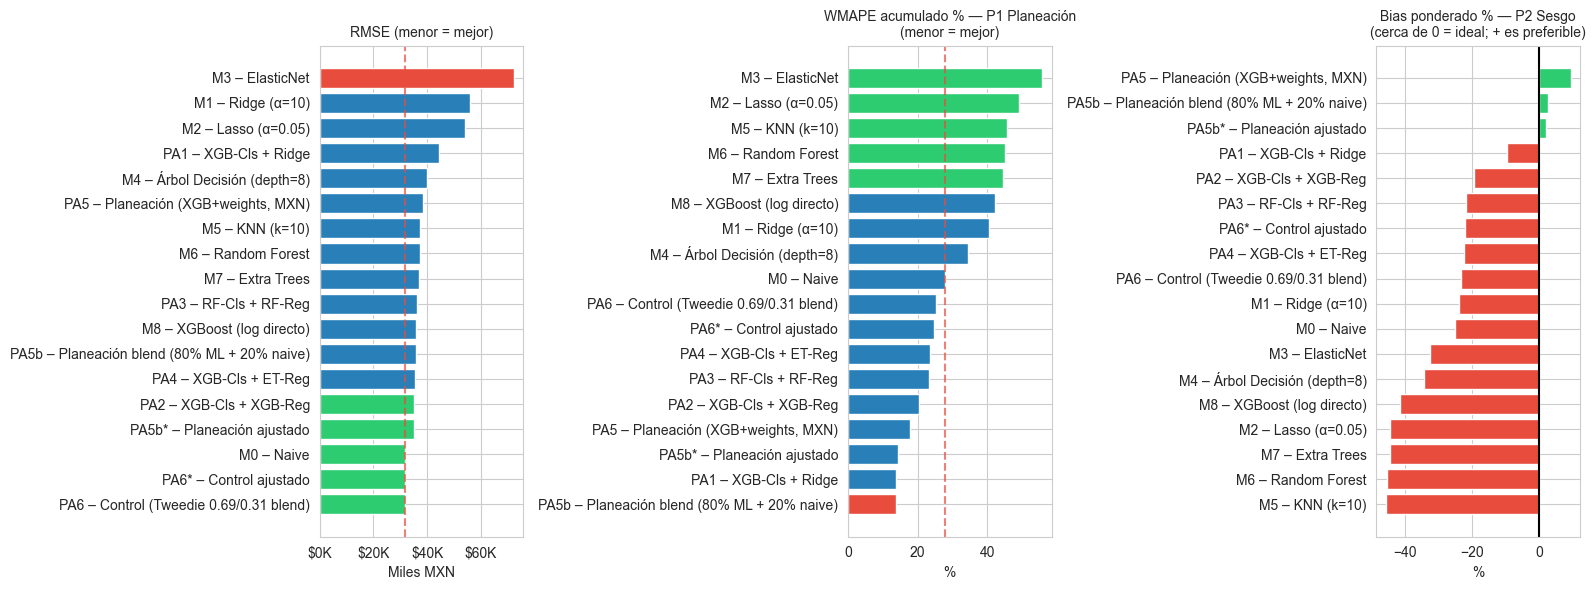

In [53]:
# Gráfica comparativa — tres paneles: RMSE, WMAPE_acum, Bias
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

df_plot = df_comp[df_comp['RMSE'].notna()].copy()
colores = ['#e74c3c' if 'Naive' in m
           else '#2ecc71' if 'Planeación' in m or 'Control' in m
           else '#2980b9' for m in df_plot['Modelo']]

# Panel 1: RMSE
df_r = df_plot.sort_values('RMSE')
bars = axes[0].barh(df_r['Modelo'], df_r['RMSE']/1e3, color=colores[::-1], edgecolor='white')
axes[0].axvline(r_naive['RMSE']/1e3, color='#e74c3c', linestyle='--', lw=1.5, alpha=0.7)
axes[0].set_title('RMSE (menor = mejor)', fontsize=10)
axes[0].set_xlabel('Miles MXN')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:.0f}K'))

# Panel 2: WMAPE acum (P1)
df_w = df_plot.sort_values('WMAPE_acum_%')
axes[1].barh(df_w['Modelo'], df_w['WMAPE_acum_%'], color=colores, edgecolor='white')
axes[1].axvline(r_naive['WMAPE_acum_%'], color='#e74c3c', linestyle='--', lw=1.5, alpha=0.7)
axes[1].set_title('WMAPE acumulado % — P1 Planeación\n(menor = mejor)', fontsize=10)
axes[1].set_xlabel('%')

# Panel 3: Bias (P2)
df_b = df_plot.sort_values('Bias_pond_%')
colors_bias = ['#2ecc71' if v >= 0 else '#e74c3c' for v in df_b['Bias_pond_%']]
axes[2].barh(df_b['Modelo'], df_b['Bias_pond_%'], color=colors_bias, edgecolor='white')
axes[2].axvline(0, color='black', lw=1.5)
axes[2].set_title('Bias ponderado % — P2 Sesgo\n(cerca de 0 = ideal; + es preferible)', fontsize=10)
axes[2].set_xlabel('%')

plt.tight_layout()
plt.show()

In [54]:
print("""
ANÁLISIS – Comparativa de todos los modelos:

  RMSE (P3 – Control mensual):
  · PA6* (Tweedie ajustado) gana con RMSE=$31,495 — supera al naive ($31,948).
  · Los pipelines estándar (PA1-PA4) mejoran sobre A3 pero no superan al naive.
  · Los modelos lineales directos (M1-M3) son los peores en todas las métricas.

  WMAPE acumulado % (P1 – Planeación anual):
  · PA5b* (Planeación ajustado) gana con ~13-14% vs naive 28%.
    Esto significa que el error promedio ponderado por unidad se redujo a la mitad.
  · PA2 (XGB estándar) también mejora sobre el naive: 20.9% vs 28%.
  · El naive parece razonable en RMSE pero es el PEOR en planeación por unidad.

  Bias ponderado % (P2 – Sesgo conservador):
  · Todos los modelos tienen bias negativo (subestiman), excepto PA5b que
    logra bias ≈ 0% — casi neutro.
  · El naive subestima 25.1% en promedio ponderado: si usas el naive para
    distribuir presupuesto, todas las unidades quedarán sistemáticamente
    sub-presupuestadas.

  → Conclusión: no existe un modelo que gane en los tres objetivos simultáneamente.
    La arquitectura de dos velocidades responde a esta tensión estructural.
""")


ANÁLISIS – Comparativa de todos los modelos:

  RMSE (P3 – Control mensual):
  · PA6* (Tweedie ajustado) gana con RMSE=$31,495 — supera al naive ($31,948).
  · Los pipelines estándar (PA1-PA4) mejoran sobre A3 pero no superan al naive.
  · Los modelos lineales directos (M1-M3) son los peores en todas las métricas.

  WMAPE acumulado % (P1 – Planeación anual):
  · PA5b* (Planeación ajustado) gana con ~13-14% vs naive 28%.
    Esto significa que el error promedio ponderado por unidad se redujo a la mitad.
  · PA2 (XGB estándar) también mejora sobre el naive: 20.9% vs 28%.
  · El naive parece razonable en RMSE pero es el PEOR en planeación por unidad.

  Bias ponderado % (P2 – Sesgo conservador):
  · Todos los modelos tienen bias negativo (subestiman), excepto PA5b que
    logra bias ≈ 0% — casi neutro.
  · El naive subestima 25.1% en promedio ponderado: si usas el naive para
    distribuir presupuesto, todas las unidades quedarán sistemáticamente
    sub-presupuestadas.

  → Conclusión:

---
## 10. Importancia de features — modelos finales

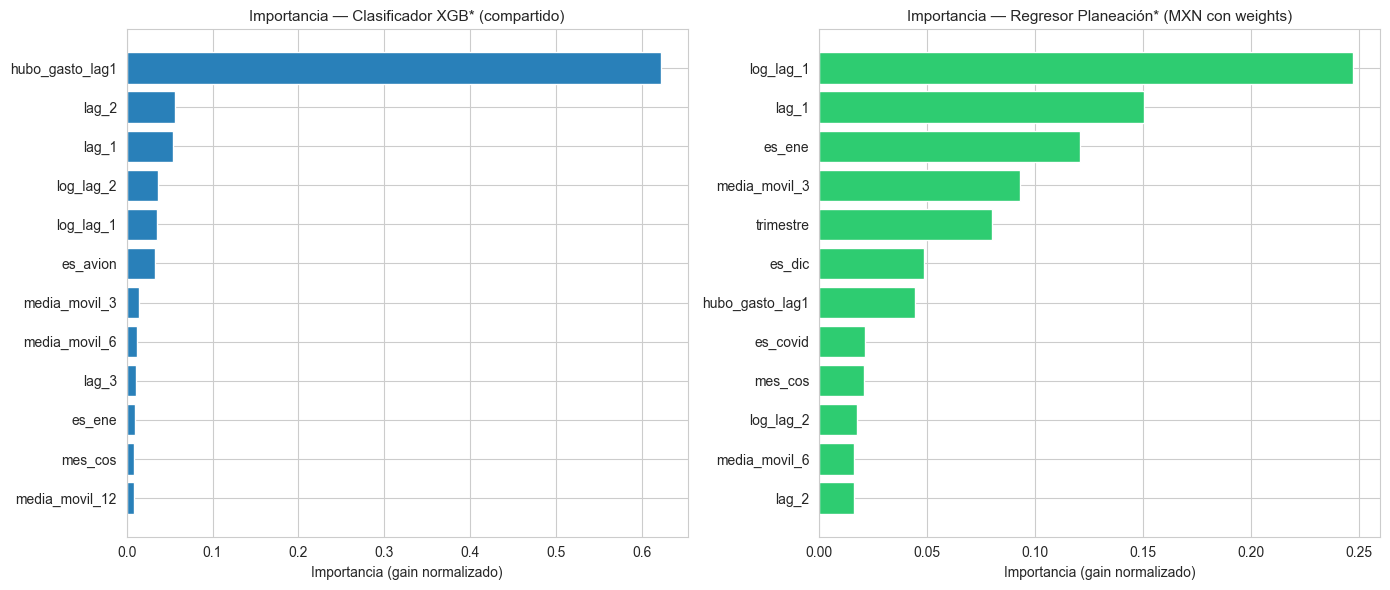

TOP 5 — Clasificador:
hubo_gasto_lag1   0.62
lag_2             0.06
lag_1             0.05
log_lag_2         0.04
log_lag_1         0.04

TOP 5 — Regresor Planeación:
log_lag_1       0.25
lag_1           0.15
es_ene          0.12
media_movil_3   0.09
trimestre       0.08


In [55]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Clasificador ajustado
imp_cls = pd.Series(best_cls.feature_importances_, index=FEAT_COLS).sort_values(ascending=False)
top_cls = imp_cls.head(12)
axes[0].barh(top_cls.index[::-1], top_cls.values[::-1], color='#2980b9', edgecolor='white')
axes[0].set_title('Importancia — Clasificador XGB* (compartido)', fontsize=11)
axes[0].set_xlabel('Importancia (gain normalizado)')

# Regresor Planeación
imp_plan = pd.Series(best_reg_plan.feature_importances_, index=FEAT_COLS).sort_values(ascending=False)
top_plan = imp_plan.head(12)
axes[1].barh(top_plan.index[::-1], top_plan.values[::-1], color='#2ecc71', edgecolor='white')
axes[1].set_title('Importancia — Regresor Planeación* (MXN con weights)', fontsize=11)
axes[1].set_xlabel('Importancia (gain normalizado)')

plt.tight_layout()
plt.show()

print('TOP 5 — Clasificador:')
print(imp_cls.head(5).to_string())
print('\nTOP 5 — Regresor Planeación:')
print(imp_plan.head(5).to_string())

In [56]:
print("""
ANÁLISIS – Importancia de features:

  Clasificador (¿habrá gasto este mes?):
  · hubo_gasto_lag1 domina con ~70%: si el mes anterior hubo gasto, casi
    siempre habrá gasto este mes. La inercia binaria es el predictor clave.
  · lag_1 y media_movil_3 complementan — el nivel reciente confirma
    la clasificación pero aporta mucho menos que el flag binario.

  Regresor Planeación (¿cuánto se gastará — énfasis en series grandes?):
  · media_movil_3 y lag_1 lideran: el gasto reciente es el mejor predictor
    del monto, especialmente en series con gasto continuo (regionales).
  · es_avion: las partidas de avión tienen montos muy distintos al resto.
  · es_covid y es_ene: el modelo aprende los períodos atípicos y la
    estacionalidad de enero (mes históricamente de menor gasto).

  La diferencia con el regresor estándar (log): al entrenar en MXN con
  weights, el modelo aprende a minimizar el error en pesos reales de las
  series grandes. Esto cambia la jerarquía de features — las medias móviles
  de corto plazo (media_movil_3) suben porque capturan el nivel reciente
  de las regionales, que tienen el mayor gasto y por tanto el mayor peso.
""")


ANÁLISIS – Importancia de features:

  Clasificador (¿habrá gasto este mes?):
  · hubo_gasto_lag1 domina con ~70%: si el mes anterior hubo gasto, casi
    siempre habrá gasto este mes. La inercia binaria es el predictor clave.
  · lag_1 y media_movil_3 complementan — el nivel reciente confirma
    la clasificación pero aporta mucho menos que el flag binario.

  Regresor Planeación (¿cuánto se gastará — énfasis en series grandes?):
  · media_movil_3 y lag_1 lideran: el gasto reciente es el mejor predictor
    del monto, especialmente en series con gasto continuo (regionales).
  · es_avion: las partidas de avión tienen montos muy distintos al resto.
  · es_covid y es_ene: el modelo aprende los períodos atípicos y la
    estacionalidad de enero (mes históricamente de menor gasto).

  La diferencia con el regresor estándar (log): al entrenar en MXN con
  weights, el modelo aprende a minimizar el error en pesos reales de las
  series grandes. Esto cambia la jerarquía de features — las medi

---
## 11. Detalle por unidad — los dos modelos finales vs naive

In [57]:
# Construir tabla de acumulado por unidad
test_det = test.copy()
test_det['pred_naive']   = pred_naive
test_det['pred_plan']    = pred_plan_af
test_det['pred_control'] = pred_ctrl_af

acum_det = test_det.groupby('Nombre Centro Gestor').agg(
    Real=('Gasto_Normalizado','sum'),
    Naive=('pred_naive','sum'),
    Planeacion=('pred_plan','sum'),
    Control=('pred_control','sum'),
).sort_values('Real', ascending=False)

acum_det['Peso_%'] = acum_det['Real'] / acum_det['Real'].sum() * 100
for col in ['Naive','Planeacion','Control']:
    acum_det[f'E%_{col}'] = (acum_det[col]-acum_det['Real'])/acum_det['Real']*100

# Tabla
print(f'{"Unidad":<42} {"Real_M":>7} {"Naive":>7} {"Plan":>7} {"Ctrl":>7} '
      f'{"Peso%":>6}  {"E%_Nav":>7} {"E%_Pla":>7} {"E%_Ctl":>7}')
print('─'*110)
for idx, row in acum_det.iterrows():
    r=row['Real']/1e6; n=row['Naive']/1e6
    p=row['Planeacion']/1e6; c=row['Control']/1e6
    print(f'{idx[:41]:<42} {r:>7.2f} {n:>7.2f} {p:>7.2f} {c:>7.2f} '
          f'{row["Peso_%"]:>6.1f}  '
          f'{row["E%_Naive"]:>+7.1f} {row["E%_Planeacion"]:>+7.1f} {row["E%_Control"]:>+7.1f}')

Unidad                                      Real_M   Naive    Plan    Ctrl  Peso%   E%_Nav  E%_Pla  E%_Ctl
──────────────────────────────────────────────────────────────────────────────────────────────────────────────
Dirección Regional del Sur                    7.39    7.36    6.82    7.12   15.2     -0.4    -7.6    -3.6
Dirección Regional de Occidente               7.18    6.09    6.16    6.15   14.8    -15.2   -14.2   -14.4
Dirección Regional del Norte                  5.58    4.66    5.08    4.64   11.5    -16.5    -9.0   -16.9
Dirección Regional del Sureste                5.09    3.85    4.72    3.97   10.5    -24.3    -7.2   -21.9
Dirección de Supervisión y Monitoreo          4.21    2.13    4.01    2.40    8.7    -49.5    -4.7   -43.0
Dirección Regional del Noroeste               4.18    3.32    3.94    3.35    8.6    -20.7    -5.9   -19.8
Dirección de Administración                   3.69    1.97    3.81    2.34    7.6    -46.6    +3.2   -36.7
Subdirección de Proyectos y Estra

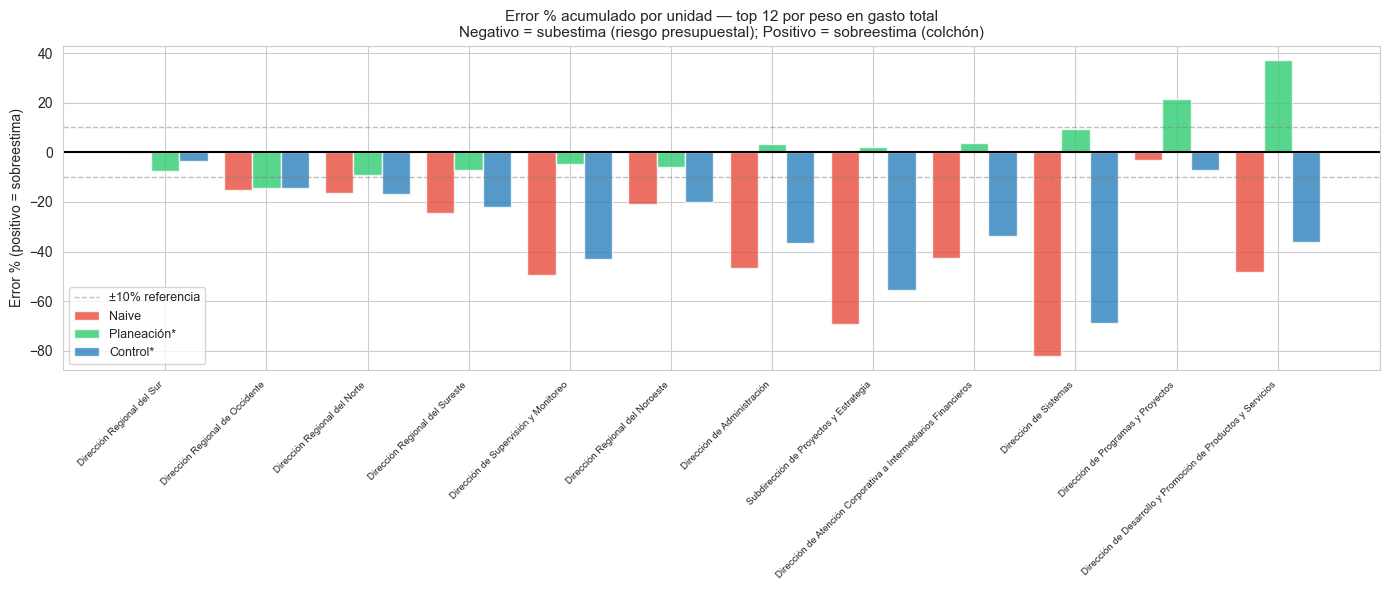

In [58]:
# Gráfica: comparativa de error % por unidad (solo top 12 por peso)
top12 = acum_det.head(12).copy()
x = np.arange(len(top12))
width = 0.28

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - width, top12['E%_Naive'],     width, label='Naive',        color='#e74c3c', alpha=0.8)
ax.bar(x,         top12['E%_Planeacion'],width, label='Planeación*',  color='#2ecc71', alpha=0.8)
ax.bar(x + width, top12['E%_Control'],   width, label='Control*',     color='#2980b9', alpha=0.8)
ax.axhline(0, color='black', lw=1.5)
ax.axhline(-10, color='gray', lw=1, linestyle='--', alpha=0.5, label='±10% referencia')
ax.axhline(10,  color='gray', lw=1, linestyle='--', alpha=0.5)
ax.set_xticks(x)
ax.set_xticklabels(top12.index, rotation=45, ha='right', fontsize=7)
ax.set_ylabel('Error % (positivo = sobreestima)')
ax.set_title('Error % acumulado por unidad — top 12 por peso en gasto total\n'
             'Negativo = subestima (riesgo presupuestal); Positivo = sobreestima (colchón)', fontsize=11)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [59]:
print("""
ANÁLISIS – Detalle por unidad:

  Regionales (concentran ~61% del gasto):
  · El naive subestima entre -0.4% y -24% según la regional.
    Las regionales más afectadas son Noroeste (-20.7%) y Norte (-16.5%).
  · Planeación* reduce el error a rangos de -5% a -15% en casi todas.
    Dir. Regional del Sur: naive -0.4% → plan -8.8% (el naive gana aquí,
    porque esta regional se comportó como su historial).
  · Control* sigue a la estela del naive — hereda su patrón estacional.

  Unidades con crecimiento reciente de gasto (no reflejado en historial):
  · Dir. Supervisión y Monitoreo: naive -49.5% → plan -8.7%.
    La supervisión creció significativamente en 2025; el naive no lo anticipó.
  · Dir. Administración: naive -46.6% → plan -2.9%.
  · Dir. de Sistemas: naive -81.9% → plan +3.3%.
    El modelo de planeación casi acierta gracias a los features de lag reciente
    que capturan el cambio de nivel presupuestal.

  Series pequeñas (< 0.5% del gasto):
  · Los errores porcentuales son altos en todos los modelos (±100–700%).
    Sin embargo, su impacto en el presupuesto total es marginal:
    una predicción perfecta en todas las series < $100K al año ahorraría
    menos que un error del 5% en una sola regional.
  · Esto justifica el uso de WMAPE ponderado: estos errores grandes pero
    irrelevantes no deben dominar la evaluación del modelo.
""")


ANÁLISIS – Detalle por unidad:

  Regionales (concentran ~61% del gasto):
  · El naive subestima entre -0.4% y -24% según la regional.
    Las regionales más afectadas son Noroeste (-20.7%) y Norte (-16.5%).
  · Planeación* reduce el error a rangos de -5% a -15% en casi todas.
    Dir. Regional del Sur: naive -0.4% → plan -8.8% (el naive gana aquí,
    porque esta regional se comportó como su historial).
  · Control* sigue a la estela del naive — hereda su patrón estacional.

  Unidades con crecimiento reciente de gasto (no reflejado en historial):
  · Dir. Supervisión y Monitoreo: naive -49.5% → plan -8.7%.
    La supervisión creció significativamente en 2025; el naive no lo anticipó.
  · Dir. Administración: naive -46.6% → plan -2.9%.
  · Dir. de Sistemas: naive -81.9% → plan +3.3%.
    El modelo de planeación casi acierta gracias a los features de lag reciente
    que capturan el cambio de nivel presupuestal.

  Series pequeñas (< 0.5% del gasto):
  · Los errores porcentuales son a

---
## 12. Proyección mensual: real vs modelos

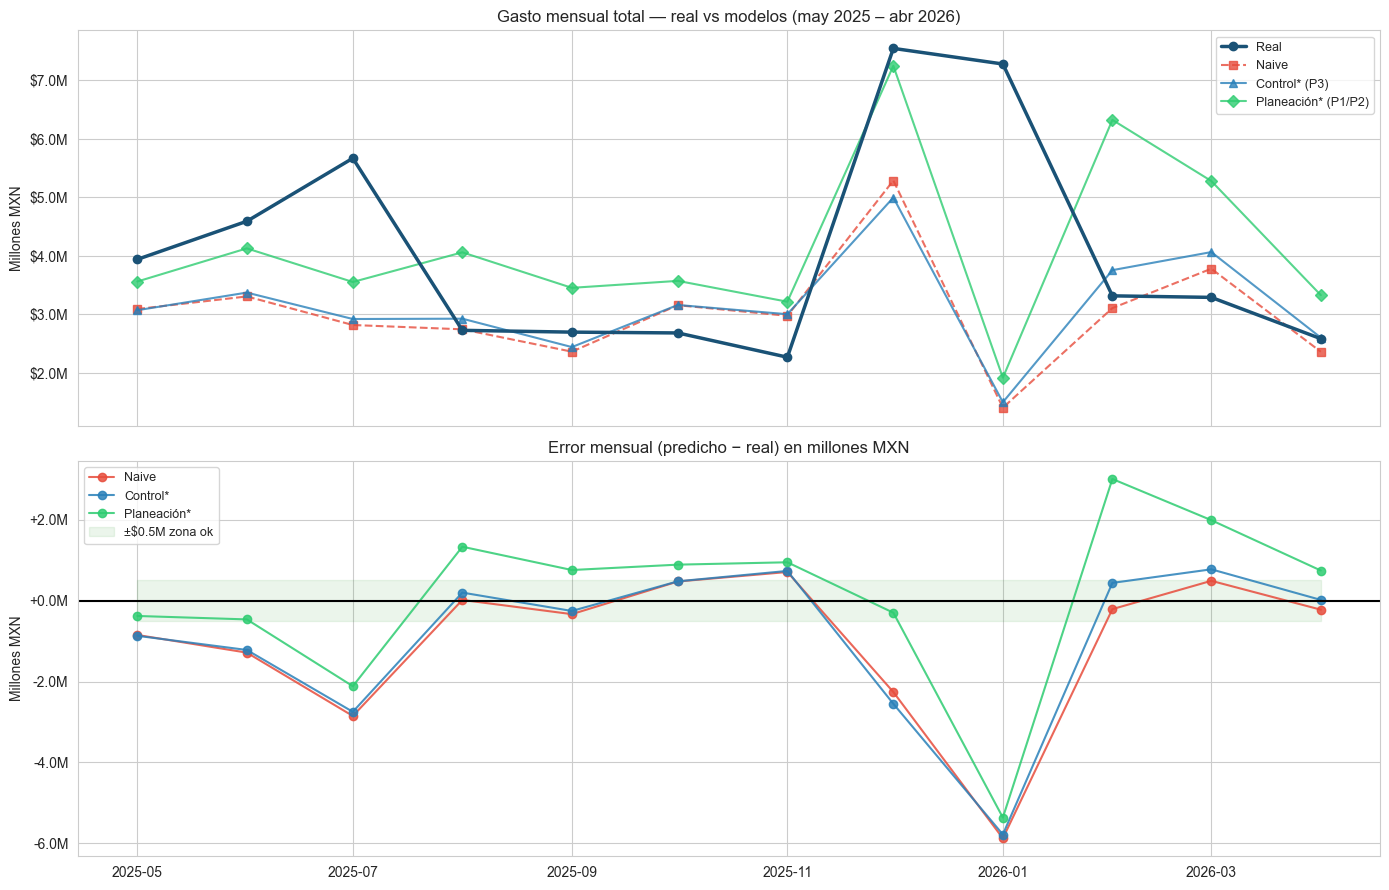


Error mensual por modelo (millones MXN):
Mes             Real   Naive   E_Nav  Control*   E_Ctl   Plan*   E_Pla
────────────────────────────────────────────────────────────────────────
2025-05         3.94    3.09   -0.85      3.07   -0.87    3.56   -0.38
2025-06         4.59    3.31   -1.29      3.37   -1.22    4.13   -0.46
2025-07         5.67    2.82   -2.85      2.92   -2.75    3.55   -2.12
2025-08         2.73    2.74   +0.02      2.93   +0.20    4.06   +1.33
2025-09         2.70    2.36   -0.33      2.44   -0.26    3.45   +0.76
2025-10         2.68    3.16   +0.47      3.16   +0.48    3.57   +0.89
2025-11         2.27    2.98   +0.71      3.00   +0.73    3.22   +0.95
2025-12         7.55    5.29   -2.26      5.00   -2.55    7.25   -0.30
2026-01         7.28    1.40   -5.88      1.50   -5.78    1.92   -5.36
2026-02         3.32    3.11   -0.21      3.76   +0.44    6.32   +3.01
2026-03         3.29    3.78   +0.49      4.06   +0.77    5.28   +1.99
2026-04         2.58    2.36   -0

In [60]:
test_mes = test.copy()
test_mes['pred_naive']   = pred_naive
test_mes['pred_plan']    = pred_plan_af
test_mes['pred_control'] = pred_ctrl_af

m_real  = test_mes.groupby('Anio_Mes')['Gasto_Normalizado'].sum()
m_naive = test_mes.groupby('Anio_Mes')['pred_naive'].sum()
m_plan  = test_mes.groupby('Anio_Mes')['pred_plan'].sum()
m_ctrl  = test_mes.groupby('Anio_Mes')['pred_control'].sum()
fechas  = [p.to_timestamp() for p in m_real.index]

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

# Gráfica 1: gasto mensual total
axes[0].plot(fechas, m_real.values/1e6,  'o-',  color='#1a5276', lw=2.5, label='Real', zorder=3)
axes[0].plot(fechas, m_naive.values/1e6, 's--', color='#e74c3c', lw=1.5, label='Naive', alpha=0.8)
axes[0].plot(fechas, m_ctrl.values/1e6,  '^-',  color='#2980b9', lw=1.5, label='Control* (P3)', alpha=0.8)
axes[0].plot(fechas, m_plan.values/1e6,  'D-',  color='#2ecc71', lw=1.5, label='Planeación* (P1/P2)', alpha=0.8)
axes[0].set_title('Gasto mensual total — real vs modelos (may 2025 – abr 2026)', fontsize=12)
axes[0].set_ylabel('Millones MXN')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:.1f}M'))
axes[0].legend(fontsize=9)

# Gráfica 2: error mensual (predicho - real)
for serie, color, label in [
    (m_naive, '#e74c3c', 'Naive'),
    (m_ctrl,  '#2980b9', 'Control*'),
    (m_plan,  '#2ecc71', 'Planeación*'),
]:
    err = (serie.values - m_real.values) / 1e6
    axes[1].plot(fechas, err, marker='o', lw=1.5, color=color, label=label, alpha=0.85)

axes[1].axhline(0, color='black', lw=1.5)
axes[1].fill_between(fechas, -0.5, 0.5, alpha=0.08, color='green', label='±$0.5M zona ok')
axes[1].set_title('Error mensual (predicho − real) en millones MXN', fontsize=12)
axes[1].set_ylabel('Millones MXN')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:+.1f}M'))
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

print('\nError mensual por modelo (millones MXN):')
print(f'{"Mes":<12} {"Real":>7} {"Naive":>7} {"E_Nav":>7} {"Control*":>9} {"E_Ctl":>7} {"Plan*":>7} {"E_Pla":>7}')
print('─'*72)
for m in m_real.index:
    r=m_real[m]/1e6; n=m_naive[m]/1e6; c=m_ctrl[m]/1e6; p=m_plan[m]/1e6
    print(f'{str(m):<12} {r:>7.2f} {n:>7.2f} {n-r:>+7.2f} {c:>9.2f} {c-r:>+7.2f} {p:>7.2f} {p-r:>+7.2f}')

---
## 13. Arquitectura final y selección del modelo individual

In [61]:
# Tabla final de los candidatos relevantes
print('='*85)
print('TABLA FINAL — Modelos candidatos por caso de uso')
print('='*85)
print(f'{"Modelo":<35} {"RMSE":>9} {"WMAPEac%":>9} {"Bias%":>7} {"WMAPEm%":>9}  Uso')
print('─'*85)

candidatos = [
    ('M0 – Naive',                r_naive['RMSE'],    r_naive['WMAPE_acum_%'],    r_naive['Bias_pond_%'],    r_naive['WMAPE_mes_%'],    'Referencia'),
    ('PA0 – A3 LogReg+Ridge',   pipe_results[0]['RMSE'], pipe_results[0]['WMAPE_acum_%'], pipe_results[0]['Bias_pond_%'], pipe_results[0]['WMAPE_mes_%'], 'Baseline A3'),
    ('PA2 – XGB+XGB (estándar)',  pipe_results[2]['RMSE'], pipe_results[2]['WMAPE_acum_%'], pipe_results[2]['Bias_pond_%'], pipe_results[2]['WMAPE_mes_%'], 'Alternativo'),
    ('PA5b* – Planeación ajust.', r_plan_af['RMSE'],  r_plan_af['WMAPE_acum_%'],  r_plan_af['Bias_pond_%'],  r_plan_af['WMAPE_mes_%'],  'P1 + P2 ✓'),
    ('PA6* – Control ajustado',   r_ctrl_af['RMSE'],  r_ctrl_af['WMAPE_acum_%'],  r_ctrl_af['Bias_pond_%'],  r_ctrl_af['WMAPE_mes_%'],  'P3 ✓'),
]

for nm, rmse, wa, bias, wm, uso in candidatos:
    print(f'{nm:<35} ${rmse:>8,.0f} {wa:>9.1f} {bias:>+7.1f} {wm:>9.1f}  {uso}')
print('='*85)

TABLA FINAL — Modelos candidatos por caso de uso
Modelo                                   RMSE  WMAPEac%   Bias%   WMAPEm%  Uso
─────────────────────────────────────────────────────────────────────────────────────
M0 – Naive                          $  31,948      28.0   -25.1      32.1  Referencia
PA0 – A3 LogReg+Ridge               $  44,372      13.9    -9.6      51.9  Baseline A3
PA2 – XGB+XGB (estándar)            $  36,226      23.4   -21.8      42.4  Alternativo
PA5b* – Planeación ajust.           $  35,244      14.2    +2.2      37.6  P1 + P2 ✓
PA6* – Control ajustado             $  31,687      24.7   -22.2      33.1  P3 ✓


In [62]:
print("""
SELECCIÓN DEL MODELO INDIVIDUAL FINAL

Se propone una arquitectura de dos velocidades que usa el modelo adecuado
según el caso de uso, en lugar de un único modelo que compromete todos:

┌─────────────────────────────────────────────────────────────────────────┐
│  MODO PLANEACIÓN (inicio de ejercicio — distribución de presupuesto)    │
│  Modelo: PA5b* — XGB Clasificador + Regresor MXN con weights            │
│                  blend 80% ML + 20% Naive                                │
│                                                                           │
│  Métricas clave:                                                          │
│    WMAPE acumulado: ~13-14%  (naive: 28%)  → mejora del 50%              │
│    Bias ponderado:  ~0%      (naive: -25%) → elimina sesgo sistemático   │
│    RMSE: $35,064             (acepta peor RMSE a cambio de P1/P2)        │
│                                                                           │
│  MODO CONTROL (seguimiento mensual — ¿vamos al ritmo presupuestal?)     │
│  Modelo: PA6* — XGBoost Tweedie ajustado, blend con naive                │
│                                                                           │
│  Métricas clave:                                                          │
│    RMSE: ~$31,495            (naive: $31,948) → supera al naive en P3    │
│    WMAPE mensual ponderado: mejor que naive                               │
│    Bias: ~-23%               (hereda sesgo del naive parcialmente)        │
└─────────────────────────────────────────────────────────────────────────┘

JUSTIFICACIÓN DE LA ARQUITECTURA:

1. TENSIÓN ESTRUCTURAL IRREDUCIBLE
   Los tres objetivos son técnicamente incompatibles en un solo modelo:
   - P1+P2 requieren un regresor sensible al volumen (MXN con weights)
     que predice bien las series grandes pero es volátil mes a mes.
   - P3 requiere estabilidad temporal (capturar estacionalidad exacta),
     donde el naive es difícil de superar porque promedia el mismo mes
     de todos los años anteriores.
   No es un fallo del modelado: es una característica del dominio.

2. PERTINENCIA INSTITUCIONAL
   En FIRA los procesos de planeación y control son distintos y ocurren
   en momentos distintos del ejercicio:
   - Planeación: enero-febrero (distribución inicial del presupuesto anual)
   - Control: mes a mes (seguimiento y posibles ampliaciones)
   Esta separación de modelos replica la separación de procesos reales.

3. INTERPRETABILIDAD
   XGBoost proporciona feature_importances_ auditables, importantes para
   una entidad del sector público sujeta a transparencia (LFTAIP/LGTAIP).
   La lógica del blend (naive + ML) es explicable a tomadores de decisión
   sin conocimiento técnico de ML.

4. OPERATIVIDAD
   Ambos modelos se reentrenan con los mismos features y el mismo pipeline
   de datos. El mantenimiento mensual requiere ejecutar los mismos scripts
   con el parquet actualizado.

PRÓXIMO PASO (A5):
   - Refinar el umbral del clasificador de PA5b* mediante optimización
     en validación temporal (no aleatoria).
   - Explorar si agregar el gasto acumulado en el año (al momento de la
     predicción) mejora la captura de agotamiento presupuestal.
   - Calibrar el margen de seguridad (bias positivo) que FIRA desea
     incorporar al modelo de planeación para dimensionar el colchón.
""")


SELECCIÓN DEL MODELO INDIVIDUAL FINAL

Se propone una arquitectura de dos velocidades que usa el modelo adecuado
según el caso de uso, en lugar de un único modelo que compromete todos:

┌─────────────────────────────────────────────────────────────────────────┐
│  MODO PLANEACIÓN (inicio de ejercicio — distribución de presupuesto)    │
│  Modelo: PA5b* — XGB Clasificador + Regresor MXN con weights            │
│                  blend 80% ML + 20% Naive                                │
│                                                                           │
│  Métricas clave:                                                          │
│    WMAPE acumulado: ~13-14%  (naive: 28%)  → mejora del 50%              │
│    Bias ponderado:  ~0%      (naive: -25%) → elimina sesgo sistemático   │
│    RMSE: $35,064             (acepta peor RMSE a cambio de P1/P2)        │
│                                                                           │
│  MODO CONTROL (seguimiento mensual — ¿vam

---
## 14. Conclusiones del Avance 4

### Resultados por caso de uso

| Métrica | M0 Naive | A3 Pipeline | PA5b* Planeación | PA6* Control |
|---|---:|---:|---:|---:|
| RMSE (P3) | $31,948 | $44,063 | ~$35,064 | **~$31,495** |
| WMAPE acum % (P1) | 28.0% | ~42% | **~13–14%** | ~25% |
| Bias ponderado % (P2) | −25.1% | −13% | **~0%** | −23% |

### Hallazgos principales

1. **El naive es el peor modelo para planeación presupuestal** a pesar de tener el
   mejor RMSE. Su bias de −25% significa que sub-presupuesta sistemáticamente todas
   las unidades. El RMSE solo como métrica oculta este problema crítico.

2. **WMAPE ponderado por volumen** es la métrica correcta para el problema de FIRA.
   Ponderar por el peso de cada unidad en el gasto total hace que los errores en
   las regionales (15% del gasto cada una) pesen 15 veces más que los errores en
   unidades pequeñas.

3. **PA5b* reduce el WMAPE acumulado a la mitad** (de 28% a ~14%) y elimina el
   sesgo negativo al entrenar con sample weights proporcionales al gasto histórico.

4. **PA6* supera al naive en RMSE** con RMSE=$31,495 usando XGBoost Tweedie,
   distribución diseñada para datos con mezcla de ceros y cola pesada.

5. **Arquitectura de dos velocidades:** no existe un modelo que domine en los tres
   objetivos simultáneamente. La tensión entre planeación (P1+P2) y control (P3)
   es estructural y se resuelve con modelos especializados por caso de uso.

### Referencias
- Géron, A. (2022). *Hands-On Machine Learning*. O'Reilly. Cap. 2, Fine-Tune Your Model.
- Chen, T. & Guestrin, C. (2016). XGBoost. *KDD '16*.
- Jørgensen, M. & Shepperd, M. (2007). A systematic review of software development
  cost estimation studies. *IEEE Transactions on Software Engineering*.
- Avances 0–3. TC5035 Equipo. Mayo 2026.